In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

EXPLORACIÓN DE DATOS (EDA) Carga y Limpieza Inicial

In [8]:
print("Cargando datos del CSV...")
df = pd.read_csv('2107_electrical_data.csv')
df['measured_on'] = pd.to_datetime(df['measured_on'])

print(f"✓ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"✓ Período: {df['measured_on'].min()} a {df['measured_on'].max()}")

cutoff_date = pd.Timestamp('2023-11-02 00:00:00')
df_clean = df[df['measured_on'] < cutoff_date].copy()

print(f"\n✓ Datos após filtrado (excl. últimos 6 días): {df_clean.shape[0]} filas")
print(f"✓ Nuevo período: {df_clean['measured_on'].min()} a {df_clean['measured_on'].max()}")

null_count_clean = df_clean.isnull().sum().sum()
print(f"✓ Celdas nulas en período limpio: {null_count_clean}")

df_clean['date'] = df_clean['measured_on'].dt.date
df_clean['hour'] = df_clean['measured_on'].dt.hour
df_clean['month'] = df_clean['measured_on'].dt.month
df_clean['year'] = df_clean['measured_on'].dt.year

df_clean['is_daytime'] = (df_clean['hour'] >= 6) & (df_clean['hour'] <= 18)

print(f"✓ Registros en horario solar (6-18h): {df_clean['is_daytime'].sum()} de {len(df_clean)}")
print("\n✓ Dataset listo para análisis.")


Cargando datos del CSV...
✓ Dataset cargado: 632952 filas × 120 columnas
✓ Período: 2017-11-01 00:00:00 a 2023-11-07 23:55:00

✓ Datos após filtrado (excl. últimos 6 días): 631224 filas
✓ Nuevo período: 2017-11-01 00:00:00 a 2023-11-01 23:55:00
✓ Celdas nulas en período limpio: 0
✓ Registros en horario solar (6-18h): 341952 de 631224

✓ Dataset listo para análisis.


In [52]:
import re

inversor_columns = {}
for inv_num in range(1, 25):
    inv_prefix = f'inv_{inv_num:02d}_'
    
    inv_cols = [col for col in df_clean.columns if col.startswith(inv_prefix)]
    
    inversor_columns[inv_num] = {
        'dc_current': None,
        'dc_voltage': None,
        'ac_current': None,
        'ac_voltage': None,
        'ac_power': None,
        'raw_columns': inv_cols
    }
    
    for col in inv_cols:
        
        if 'dc_current' in col:
            inversor_columns[inv_num]['dc_current'] = col
        elif 'dc_voltage' in col:
            inversor_columns[inv_num]['dc_voltage'] = col
        elif 'ac_current' in col:
            inversor_columns[inv_num]['ac_current'] = col
        elif 'ac_voltage' in col:
            inversor_columns[inv_num]['ac_voltage'] = col
        elif 'ac_power' in col or 'ac_power_iinv' in col:  
            inversor_columns[inv_num]['ac_power'] = col


print(" MAPEO DE INVERSORES \n")
excepciones = []
for inv_num, cols_dict in inversor_columns.items():
    status = "✓ Completo"
    if cols_dict['dc_voltage'] is None:
        status = "Sin dc_voltage"
        excepciones.append((inv_num, "dc_voltage"))
    if cols_dict['ac_power'] is None:
        status = "✗ Sin ac_power"
        excepciones.append((inv_num, "ac_power"))
    print(f"inv_{inv_num:02d}: {status}")

if excepciones:
    print(f"\n Excepciones detectadas:")
    for inv_num, col_type in excepciones:
        print(f"  - inv_{inv_num:02d}: falta '{col_type}'")


 MAPEO DE INVERSORES 

inv_01: ✓ Completo
inv_02: ✓ Completo
inv_03: ✓ Completo
inv_04: ✓ Completo
inv_05: Sin dc_voltage
inv_06: ✓ Completo
inv_07: ✓ Completo
inv_08: ✓ Completo
inv_09: ✓ Completo
inv_10: ✓ Completo
inv_11: ✓ Completo
inv_12: ✓ Completo
inv_13: ✓ Completo
inv_14: ✓ Completo
inv_15: ✓ Completo
inv_16: ✓ Completo
inv_17: ✓ Completo
inv_18: ✓ Completo
inv_19: ✓ Completo
inv_20: ✓ Completo
inv_21: ✓ Completo
inv_22: ✓ Completo
inv_23: ✓ Completo
inv_24: ✓ Completo

 Excepciones detectadas:
  - inv_05: falta 'dc_voltage'


Cálculo de Eficiencia por Inversor

In [53]:
efficiency_data = {}

for inv_num, cols_dict in inversor_columns.items():

    dc_current_col = cols_dict['dc_current']
    dc_voltage_col = cols_dict['dc_voltage']
    ac_power_col = cols_dict['ac_power']

    if dc_current_col and ac_power_col:

        i_dc = df_clean[dc_current_col].values
        p_ac = df_clean[ac_power_col].values

        if dc_voltage_col is not None:
            v_dc = df_clean[dc_voltage_col].values
        else:

            valid_voltages = []

            for inv_cols in inversor_columns.values():
                if inv_cols['dc_voltage'] is not None:
                    vals = df_clean[inv_cols['dc_voltage']]
                    vals = vals[vals < 2000]
                    valid_voltages.append(vals.mean())

            v_dc_avg = np.nanmean(valid_voltages)

            print(
                f"inv_{inv_num:02d}: usando "
                f"V_DC promedio = {v_dc_avg:.2f}V como estimación"
            )

            v_dc = np.full_like(i_dc, v_dc_avg, dtype=float)

        
        p_dc = (i_dc * v_dc) / 1000

      
        daytime_mask = df_clean['is_daytime'].values
        valid_dc_mask = p_dc > 0.1
        compute_mask = daytime_mask & valid_dc_mask

        
        efficiency = np.full_like(p_ac, np.nan, dtype=float)

        
        efficiency[compute_mask] = (
            p_ac[compute_mask] /
            p_dc[compute_mask]
        )

       
        efficiency[efficiency < 0] = np.nan
        efficiency[efficiency > 1.20] = np.nan

        
        df_clean[f'inv_{inv_num:02d}_efficiency'] = efficiency

        
        total_dc = np.nansum(p_dc[compute_mask])
        total_ac = np.nansum(p_ac[compute_mask])

        energy_weighted_eff = (
            total_ac / total_dc
            if total_dc > 0
            else np.nan
        )

       
        valid_eff = efficiency[~np.isnan(efficiency)]

        
        if len(valid_eff) == 0:
            print(f"inv_{inv_num:02d}: sin datos válidos")
            continue

       
        cv = (
            np.std(valid_eff, ddof=1) /
            np.mean(valid_eff)
            if np.mean(valid_eff) > 0
            else np.nan
        )

        
        efficiency_data[inv_num] = {
            'mean': np.mean(valid_eff),
            'median': np.median(valid_eff),
            'std': np.std(valid_eff, ddof=1),
            'cv': cv,
            'min': np.min(valid_eff),
            'max': np.max(valid_eff),
            'count': len(valid_eff),
            'missing_dc_voltage': dc_voltage_col is None,
            'energy_weighted': energy_weighted_eff
        }


print("\n ESTADÍSTICAS DE EFICIENCIA (HORARIO SOLAR) \n")

print(
    f"{'Inv':<6} {'Media':<8} {'Mediana':<8} "
    f"{'Desv':<8} {'CV':<8} {'Min':<8} "
    f"{'Max':<8} {'N':<8} {'Nota':<25}"
)

print("-" * 100)

for inv_num in sorted(efficiency_data.keys()):

    stats = efficiency_data[inv_num]
    nota = "Sin dc_voltage" if stats['missing_dc_voltage'] else ""

    print(
        f"inv_{inv_num:02d}  "
        f"{stats['mean']:.4f}  "
        f"{stats['median']:.4f}  "
        f"{stats['std']:.4f}  "
        f"{stats['cv']:.4f}  "
        f"{stats['min']:.4f}  "
        f"{stats['max']:.4f}  "
        f"{stats['count']:<8} "
        f"{nota}"
    )


print("\nParque completo:")

means = [e['mean'] for e in efficiency_data.values()]
medians = [e['median'] for e in efficiency_data.values()]
weighted = [e['energy_weighted'] for e in efficiency_data.values()]

print(f"  Eficiencia promedio: {np.mean(means):.4f}")
print(f"  Mediana: {np.median(medians):.4f}")
print(f"  Eficiencia ponderada: {np.nanmean(weighted):.4f}")
print(f"  Desv. Std: {np.std(means, ddof=1):.4f}")

inv_05: usando V_DC promedio = 326.65V como estimación

 ESTADÍSTICAS DE EFICIENCIA (HORARIO SOLAR) 

Inv    Media    Mediana  Desv     CV       Min      Max      N        Nota                     
----------------------------------------------------------------------------------------------------
inv_01  0.8763  0.9685  0.2247  0.2564  0.0000  1.1985  277356   
inv_02  0.9120  0.9732  0.1861  0.2041  0.0000  1.1988  264230   
inv_03  0.9222  0.9757  0.1737  0.1884  0.0000  1.1994  280799   
inv_04  0.9488  0.9770  0.1163  0.1226  0.0000  1.1999  258029   
inv_05  0.6551  0.7561  0.4032  0.6155  0.0000  1.2000  11045    Sin dc_voltage
inv_06  0.8977  0.9741  0.2095  0.2334  0.0000  1.1986  260465   
inv_07  0.9407  0.9819  0.1446  0.1537  0.0000  1.1991  248901   
inv_08  0.9224  0.9681  0.1542  0.1672  0.0000  1.1971  273510   
inv_09  0.9356  0.9798  0.1540  0.1646  0.0000  1.1992  284273   
inv_10  0.9373  0.9817  0.1517  0.1619  0.0000  1.1983  277814   
inv_11  0.9468  0.9785  0.1

In [56]:
excluidos = [5, 7]
ranking = {inv: stats['energy_weighted'] 
           for inv, stats in efficiency_data.items() 
           if inv not in excluidos}

ranking_ordenado = sorted(ranking.items(), key=lambda x: x[1])
print(" RANKING DE EFICIENCIA REAL (excluyendo inv_05 e inv_07) \n")
for inv, eff in ranking_ordenado:
    print(f"inv_{inv:02d}: {eff:.4f}")

import numpy as np
valores = list(ranking.values())
p10 = np.percentile(valores, 10)
print(f"\nUmbral P10: {p10:.4f}")
print("Inversores por debajo del P10:", [inv for inv, eff in ranking.items() if eff < p10])

 RANKING DE EFICIENCIA REAL (excluyendo inv_05 e inv_07) 

inv_01: 0.9670
inv_08: 0.9694
inv_21: 0.9722
inv_13: 0.9742
inv_02: 0.9749
inv_06: 0.9753
inv_19: 0.9775
inv_20: 0.9777
inv_17: 0.9779
inv_23: 0.9782
inv_04: 0.9782
inv_16: 0.9782
inv_03: 0.9782
inv_18: 0.9785
inv_15: 0.9788
inv_11: 0.9796
inv_09: 0.9815
inv_24: 0.9817
inv_12: 0.9817
inv_10: 0.9830
inv_22: 0.9844
inv_14: 0.9851

Umbral P10: 0.9724
Inversores por debajo del P10: [1, 8, 21]


Visualización Comparativa de Eficiencia

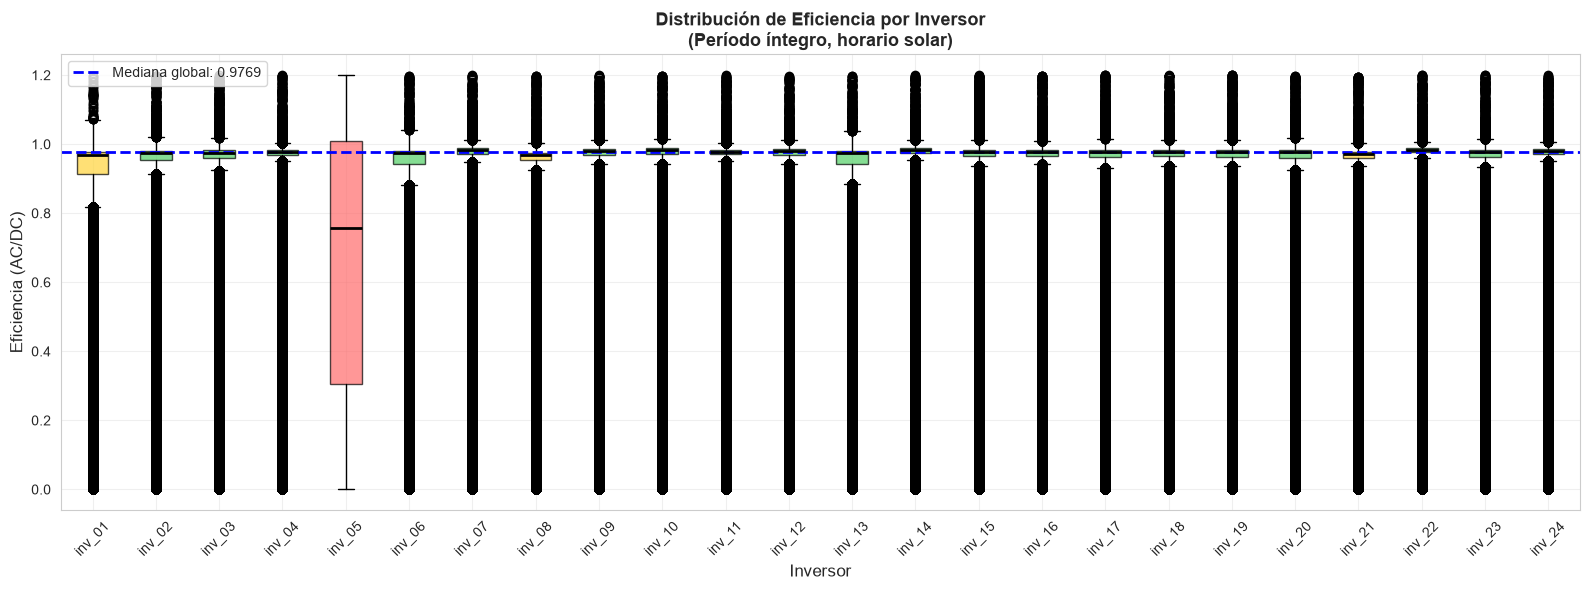

✓ Gráfico 1 (Boxplot) completado


In [57]:
fig, ax = plt.subplots(figsize=(16,6))

efficiency_by_inv = []
inv_labels = []

for inv_num in range(1,25):

    col_name = f'inv_{inv_num:02d}_efficiency'

    if col_name in df_clean.columns:

        eff = df_clean[col_name].dropna().values

        if len(eff) > 0:
            efficiency_by_inv.append(eff)
            inv_labels.append(f'inv_{inv_num:02d}')

bp = ax.boxplot(
    efficiency_by_inv,
    tick_labels=inv_labels,
    patch_artist=True
)

valid_medians = [
    np.median(e)
    for e in efficiency_by_inv
]

global_median = np.median(valid_medians)

colors = []

for e in efficiency_by_inv:

    median_eff = np.median(e)

    if median_eff < global_median - 0.01:
        colors.append('#ff6b6b')

    elif median_eff < global_median - 0.005:
        colors.append('#ffd43b')

    else:
        colors.append('#51cf66')

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.axhline(
    y=global_median,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mediana global: {global_median:.4f}'
)

ax.set_ylabel('Eficiencia (AC/DC)', fontsize=12)
ax.set_xlabel('Inversor', fontsize=12)

ax.set_title(
    'Distribución de Eficiencia por Inversor\n'
    '(Período íntegro, horario solar)',
    fontsize=13,
    fontweight='bold'
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Gráfico 1 (Boxplot) completado")

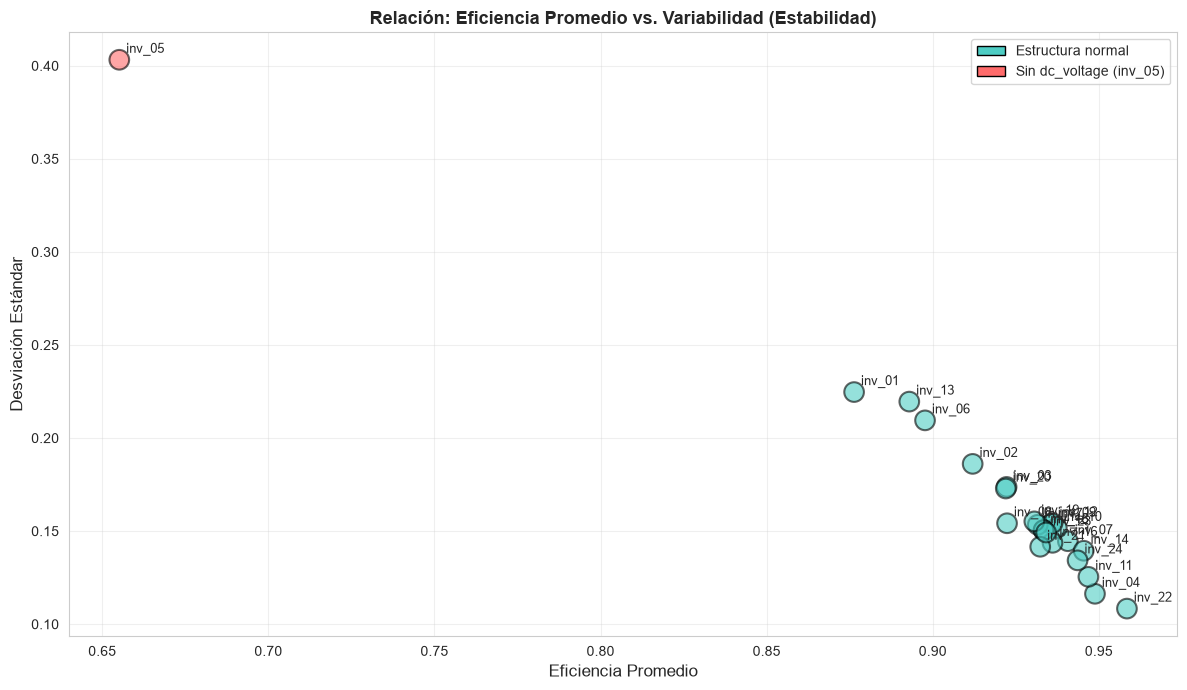

✓ Gráfico 2 (Media vs. Desv. Std) completado


In [58]:
fig, ax = plt.subplots(figsize=(12, 7))

means = []
stds = []
inv_nums = []
colors_scatter = []

for inv_num in sorted(efficiency_data.keys()):
    stats = efficiency_data[inv_num]
    means.append(stats['mean'])
    stds.append(stats['std'])
    inv_nums.append(inv_num)
    
    if stats['missing_dc_voltage']:
        colors_scatter.append('#ff6b6b')
    else:
        colors_scatter.append('#4ecdc4')

scatter = ax.scatter(means, stds, s=200, c=colors_scatter, alpha=0.6, edgecolors='black', linewidth=1.5)

for i, inv_num in enumerate(inv_nums):
    ax.annotate(f'inv_{inv_num:02d}', (means[i], stds[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Eficiencia Promedio', fontsize=12)
ax.set_ylabel('Desviación Estándar', fontsize=12)
ax.set_title('Relación: Eficiencia Promedio vs. Variabilidad (Estabilidad)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4ecdc4', edgecolor='black', label='Estructura normal'),
                   Patch(facecolor='#ff6b6b', edgecolor='black', label='Sin dc_voltage (inv_05)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

print("✓ Gráfico 2 (Media vs. Desv. Std) completado")


Ranking de Inversores por Rendimiento (KPI 1 y 3)

In [60]:
ranking_df = pd.DataFrame([
    {
        'Inversor': f'inv_{inv_num:02d}',
        'Eficiencia Media': efficiency_data[inv_num]['mean'],
        'Mediana': efficiency_data[inv_num]['median'],
        'Desv. Std': efficiency_data[inv_num]['std'],
        'Mín': efficiency_data[inv_num]['min'],
        'Máx': efficiency_data[inv_num]['max'],
        'N Muestras': efficiency_data[inv_num]['count'],
    }
    for inv_num in sorted(efficiency_data.keys())
])

ranking_df_sorted = ranking_df.sort_values('Eficiencia Media', ascending=False).reset_index(drop=True)
ranking_df_sorted['Rango'] = range(1, len(ranking_df_sorted) + 1)

p10_efficiency = ranking_df_sorted['Eficiencia Media'].quantile(0.10)
p25_efficiency = ranking_df_sorted['Eficiencia Media'].quantile(0.25)

print("RANKING DE INVERSORES POR EFICIENCIA\n")
print(ranking_df_sorted[['Rango', 'Inversor', 'Eficiencia Media', 'Mediana', 'Desv. Std', 'N Muestras']].to_string(index=False))

print(f"\nUMBRALES ESTADÍSTICOS")
print(f"Percentil 90 (P90): {ranking_df_sorted['Eficiencia Media'].quantile(0.90):.4f}")
print(f"Percentil 75 (Q3):  {ranking_df_sorted['Eficiencia Media'].quantile(0.75):.4f}")
print(f"Mediana (P50):      {ranking_df_sorted['Eficiencia Media'].median():.4f}")
print(f"Percentil 25 (Q1):  {p25_efficiency:.4f}")
print(f"Percentil 10 (P10): {p10_efficiency:.4f} ← Umbral de BAJO rendimiento")

anomalous_inversors = ranking_df_sorted[ranking_df_sorted['Eficiencia Media'] < p10_efficiency]
kpi1_rate = (len(anomalous_inversors) / len(ranking_df_sorted)) * 100

print(f"\n=== KPI 1: TASA DE INVERSORES ANÓMALOS ===")
print(f"Inversores con eficiencia < P10 ({p10_efficiency:.4f}): {len(anomalous_inversors)}")
print(f"Tasa: {kpi1_rate:.1f}% ({len(anomalous_inversors)}/{len(ranking_df_sorted)})")
print(f"Meta: ≤ 10% → {'✓ CUMPLIDA' if kpi1_rate <= 10 else '✗ NO CUMPLIDA'}\n")

if len(anomalous_inversors) > 0:
    print("Inversores en ALERTA:")
    for idx, row in anomalous_inversors.iterrows():
        print(f"  {row['Inversor']}: {row['Eficiencia Media']:.4f}")


RANKING DE INVERSORES POR EFICIENCIA

 Rango Inversor  Eficiencia Media  Mediana  Desv. Std  N Muestras
     1   inv_22          0.958450 0.983718   0.108359      283596
     2   inv_04          0.948826 0.976994   0.116320      258029
     3   inv_11          0.946845 0.978464   0.125427      284668
     4   inv_14          0.945436 0.984041   0.139438      276210
     5   inv_24          0.943586 0.980425   0.134287      267903
     6   inv_07          0.940661 0.981875   0.144569      248901
     7   inv_10          0.937345 0.981705   0.151714      277814
     8   inv_12          0.936068 0.979760   0.154270      286345
     9   inv_16          0.936044 0.976906   0.143704      277374
    10   inv_09          0.935584 0.979772   0.153970      284273
    11   inv_23          0.934115 0.977463   0.149250      272611
    12   inv_18          0.933368 0.977003   0.150470      283663
    13   inv_15          0.933354 0.977539   0.150554      282783
    14   inv_21          0.932339 0.97

Análisis de Evolución Temporal y Degradación (KPI 3: DEI)

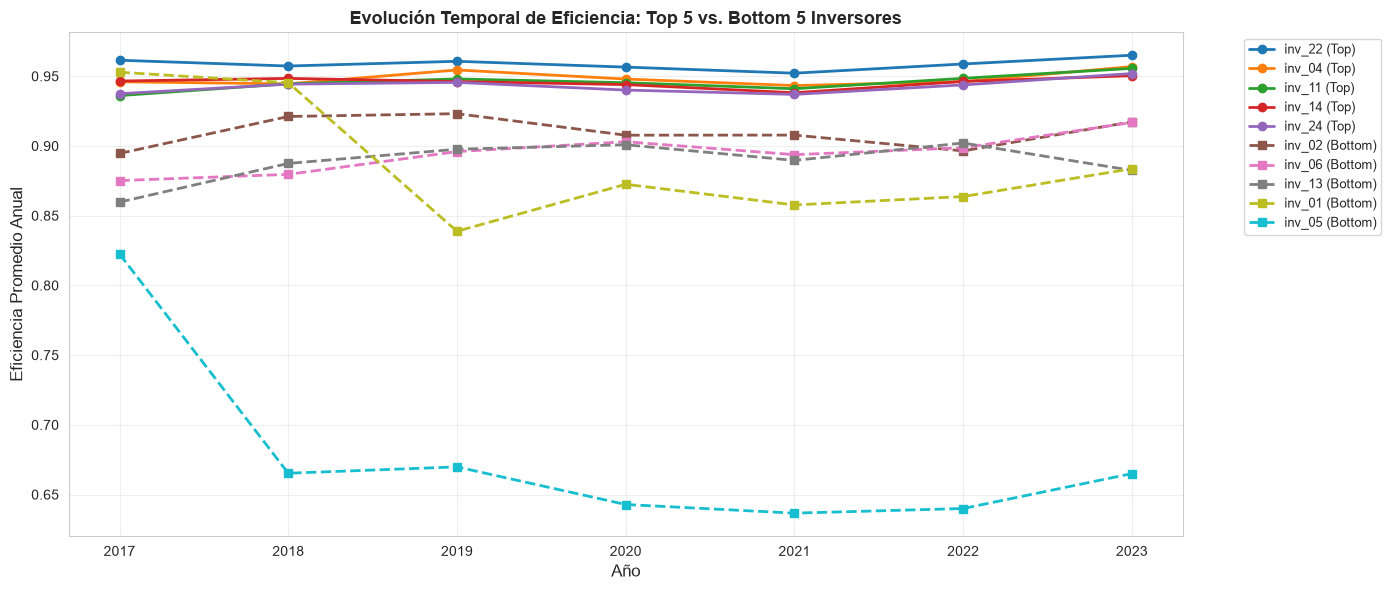

✓ Gráfico 3 (Evolución Temporal) completado

 KPI 3: ÍNDICE DE DESVIACIÓN DE EFICIENCIA (DEI) 

Inversor     Eff 2017   Eff 2023   DEI %      Estado              
-----------------------------------------------------------------
inv_01      0.9529      0.8837      +7.3%      🟢 NORMAL
inv_02      0.8946      0.9173      -2.5%      🟢 NORMAL
inv_03      0.8841      0.9364      -5.9%      🟢 NORMAL
inv_04      0.9460      0.9569      -1.2%      🟢 NORMAL
inv_05      0.8225      0.6650      +19.1%      🟡 MODERADA
inv_06      0.8752      0.9168      -4.8%      🟢 NORMAL
inv_07      0.9262      0.9509      -2.7%      🟢 NORMAL
inv_08      0.9170      0.9289      -1.3%      🟢 NORMAL
inv_09      0.9096      0.9452      -3.9%      🟢 NORMAL
inv_10      0.9379      0.9467      -0.9%      🟢 NORMAL
inv_11      0.9361      0.9556      -2.1%      🟢 NORMAL
inv_12      0.9164      0.9452      -3.1%      🟢 NORMAL
inv_13      0.8597      0.8825      -2.6%      🟢 NORMAL
inv_14      0.9465      0.9504      -0.4

In [61]:
efficiency_by_year = {}

for inv_num in range(1, 25):
    col_name = f'inv_{inv_num:02d}_efficiency'
    if col_name in df_clean.columns:
        efficiency_by_year[inv_num] = df_clean.groupby('year')[col_name].mean()

fig, ax = plt.subplots(figsize=(14, 6))

top_5_inversors = ranking_df_sorted.head(5)['Inversor'].str.extract('(\d+)').values.flatten().astype(int)
bottom_5_inversors = ranking_df_sorted.tail(5)['Inversor'].str.extract('(\d+)').values.flatten().astype(int)

for inv_num in top_5_inversors:
    if inv_num in efficiency_by_year:
        data = efficiency_by_year[inv_num]
        ax.plot(data.index, data.values, marker='o', linewidth=2, label=f'inv_{inv_num:02d} (Top)', linestyle='-')

for inv_num in bottom_5_inversors:
    if inv_num in efficiency_by_year:
        data = efficiency_by_year[inv_num]
        ax.plot(data.index, data.values, marker='s', linewidth=2, label=f'inv_{inv_num:02d} (Bottom)', linestyle='--')

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Eficiencia Promedio Anual', fontsize=12)
ax.set_title('Evolución Temporal de Eficiencia: Top 5 vs. Bottom 5 Inversores', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Gráfico 3 (Evolución Temporal) completado")

print(f"\n KPI 3: ÍNDICE DE DESVIACIÓN DE EFICIENCIA (DEI) \n")
print(f"{'Inversor':<12} {'Eff 2017':<10} {'Eff 2023':<10} {'DEI %':<10} {'Estado':<20}")
print("-" * 65)

dei_alerts_moderate = []
dei_alerts_critical = []

for inv_num in range(1, 25):
    if inv_num in efficiency_by_year:
        eff_2017 = efficiency_by_year[inv_num].get(2017, np.nan)
        eff_2023 = efficiency_by_year[inv_num].get(2023, np.nan)
        
        if not np.isnan(eff_2017) and not np.isnan(eff_2023):
            dei = ((eff_2017 - eff_2023) / eff_2017) * 100
            
            if dei > 20:
                status = "🔴 CRÍTICA"
                dei_alerts_critical.append((inv_num, dei))
            elif dei > 10:
                status = "🟡 MODERADA"
                dei_alerts_moderate.append((inv_num, dei))
            else:
                status = "🟢 NORMAL"
            
            print(f"inv_{inv_num:02d}      {eff_2017:.4f}      {eff_2023:.4f}      {dei:+.1f}%      {status}")

print(f"\nAlertas DEI > 10%: {len(dei_alerts_moderate) + len(dei_alerts_critical)} inversores")
print(f"  Críticas (> 20%): {len(dei_alerts_critical)}")
print(f"  Moderadas (10-20%): {len(dei_alerts_moderate)}")


ANÁLISIS NO SUPERVISADO — CLUSTERING DE INVERSORES/Clustering K-Means

In [63]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("FASE 3 (ACTUALIZADA): CLUSTERING K-MEANS CON DATOS CORREGIDOS")
print("\nExcluyendo: inv_05 (sin sensor dc_voltage real), inv_07 (voltaje corrupto)")
print(f"Inversores válidos para clustering: {len(ranking)} de 24\n")

X_cluster_valid = np.array([[
    efficiency_data[inv_num]['mean'],
    efficiency_data[inv_num]['median'],
    efficiency_data[inv_num]['std'],
    efficiency_data[inv_num]['energy_weighted']
] for inv_num in sorted([inv for inv in efficiency_data.keys() if inv in ranking])])

inv_nums_valid = sorted([inv for inv in efficiency_data.keys() if inv in ranking])
print(f"Inversores en análisis: {[f'inv_{i:02d}' for i in inv_nums_valid]}\n")

scaler_valid = StandardScaler()
X_cluster_valid_scaled = scaler_valid.fit_transform(X_cluster_valid)

inertias_valid = []
silhouette_scores_valid = []
k_range_valid = range(2, 7)

for k in k_range_valid:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_cluster_valid_scaled)
    inertias_valid.append(kmeans_test.inertia_)
    sil_score_test = silhouette_score(X_cluster_valid_scaled, kmeans_test.labels_)
    silhouette_scores_valid.append(sil_score_test)

optimal_k_valid = list(k_range_valid)[np.argmax(silhouette_scores_valid)]

print(f" SELECCIÓN DE K ÓPTIMO (CON 22 INVERSORES VÁLIDOS) \n")
print(f"{'K':<6} {'Silhouette Score':<20} {'Inercia':<15}")
print("-" * 42)
for k, sil, inertia in zip(k_range_valid, silhouette_scores_valid, inertias_valid):
    marker = "← ÓPTIMO" if k == optimal_k_valid else ""
    print(f"{k:<6} {sil:<20.4f} {inertia:<15.2f} {marker}")

kmeans_valid = KMeans(n_clusters=optimal_k_valid, random_state=42, n_init=10)
cluster_labels_valid = kmeans_valid.fit_predict(X_cluster_valid_scaled)

print(f"\n✓ Clustering completado con K = {optimal_k_valid}")
print(f"✓ Silhouette Score: {silhouette_scores_valid[optimal_k_valid - 2]:.4f}")
print(f"✓ COMPARACIÓN: Score anterior (24 inv, defectuosos): 0.8623 → Score actual (22 inv, válidos): {silhouette_scores_valid[optimal_k_valid - 2]:.4f}")

if silhouette_scores_valid[optimal_k_valid - 2] > 0.8623:
    print(f"   ➜ Mejora: +{(silhouette_scores_valid[optimal_k_valid - 2] - 0.8623)*100:.2f}% → Datos corregidos = clusters más cohesivos")
else:
    print(f"   ➜ Cambio: {(silhouette_scores_valid[optimal_k_valid - 2] - 0.8623)*100:.2f}% → Efecto de excluir outliers")

cluster_assignment_valid = {}
for idx, (inv_num, label) in enumerate(zip(inv_nums_valid, cluster_labels_valid)):
    cluster_assignment_valid[inv_num] = label

print(f"\n COMPOSICIÓN DE CLUSTERS (CON ENERGY_WEIGHTED) \n")
for c in range(optimal_k_valid):
    inv_in_cluster_valid = sorted([inv for inv, label in cluster_assignment_valid.items() if label == c])
    inv_labels_cluster = [f'inv_{inv:02d}' for inv in inv_in_cluster_valid]
    avg_eff_weighted = np.mean([efficiency_data[inv]['energy_weighted'] for inv in inv_in_cluster_valid])
    avg_eff_simple = np.mean([efficiency_data[inv]['mean'] for inv in inv_in_cluster_valid])
    print(f"Cluster {c} ({len(inv_in_cluster_valid)} inversores):")
    print(f"  Inversores: {', '.join(inv_labels_cluster)}")
    print(f"  Eficiencia (energy_weighted): {avg_eff_weighted:.4f}")
    print(f"  Eficiencia (simple mean): {avg_eff_simple:.4f}")
    print()


FASE 3 (ACTUALIZADA): CLUSTERING K-MEANS CON DATOS CORREGIDOS

Excluyendo: inv_05 (sin sensor dc_voltage real), inv_07 (voltaje corrupto)
Inversores válidos para clustering: 22 de 24

Inversores en análisis: ['inv_01', 'inv_02', 'inv_03', 'inv_04', 'inv_06', 'inv_08', 'inv_09', 'inv_10', 'inv_11', 'inv_12', 'inv_13', 'inv_14', 'inv_15', 'inv_16', 'inv_17', 'inv_18', 'inv_19', 'inv_20', 'inv_21', 'inv_22', 'inv_23', 'inv_24']

 SELECCIÓN DE K ÓPTIMO (CON 22 INVERSORES VÁLIDOS) 

K      Silhouette Score     Inercia        
------------------------------------------
2      0.5188               38.24           ← ÓPTIMO
3      0.3630               25.72           
4      0.3861               17.30           
5      0.4173               11.90           
6      0.4368               8.57            

✓ Clustering completado con K = 2
✓ Silhouette Score: 0.5188
✓ COMPARACIÓN: Score anterior (24 inv, defectuosos): 0.8623 → Score actual (22 inv, válidos): 0.5188
   ➜ Cambio: -34.35% → Efecto de e

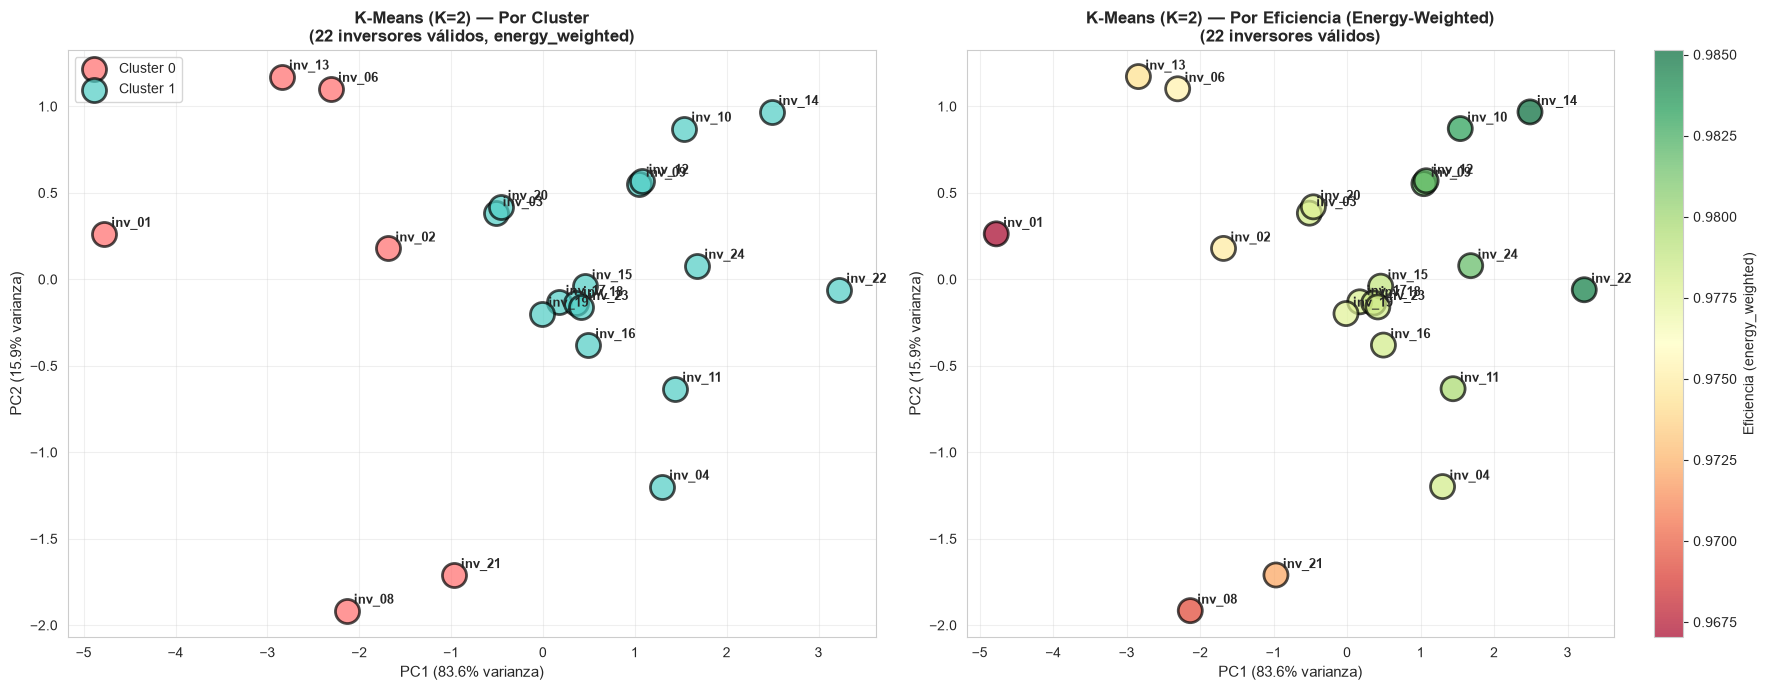

✓ Visualización PCA 2D completada
✓ Varianza explicada (PC1 + PC2): 99.6%

 NOTA SOBRE LA MÉTRICA:
   • energy_weighted = Σ(P_AC) / Σ(P_DC) = Eficiencia REAL (no sesgada por transientes)
   • mean = Promedio simple de eficiencia instantánea (sesgado por amanecer/atardecer)
   → El clustering usa ambas para capturar patrones de comportamiento global


In [64]:
from sklearn.decomposition import PCA

pca_valid = PCA(n_components=2)
X_pca_valid = pca_valid.fit_transform(X_cluster_valid_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors_cluster = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for c in range(optimal_k_valid):
    mask = cluster_labels_valid == c
    ax1.scatter(X_pca_valid[mask, 0], X_pca_valid[mask, 1], s=300, c=[colors_cluster[c]], 
              label=f'Cluster {c}', alpha=0.7, edgecolors='black', linewidth=2)

for idx, inv_num in enumerate(inv_nums_valid):
    ax1.annotate(f'inv_{inv_num:02d}', (X_pca_valid[idx, 0], X_pca_valid[idx, 1]),
               xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax1.set_xlabel(f'PC1 ({pca_valid.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_valid.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax1.set_title(f'K-Means (K={optimal_k_valid}) — Por Cluster\n(22 inversores válidos, energy_weighted)', 
             fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

eff_weighted_valid = np.array([efficiency_data[inv]['energy_weighted'] for inv in inv_nums_valid])
scatter = ax2.scatter(X_pca_valid[:, 0], X_pca_valid[:, 1], s=300, c=eff_weighted_valid, 
                     cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=2, vmin=eff_weighted_valid.min(), 
                     vmax=eff_weighted_valid.max())

for idx, inv_num in enumerate(inv_nums_valid):
    ax2.annotate(f'inv_{inv_num:02d}', (X_pca_valid[idx, 0], X_pca_valid[idx, 1]),
               xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax2.set_xlabel(f'PC1 ({pca_valid.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_valid.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax2.set_title(f'K-Means (K={optimal_k_valid}) — Por Eficiencia (Energy-Weighted)\n(22 inversores válidos)', 
             fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax2, label='Eficiencia (energy_weighted)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualización PCA 2D completada")
print(f"✓ Varianza explicada (PC1 + PC2): {(pca_valid.explained_variance_ratio_[0] + pca_valid.explained_variance_ratio_[1])*100:.1f}%")
print(f"\n NOTA SOBRE LA MÉTRICA:")
print(f"   • energy_weighted = Σ(P_AC) / Σ(P_DC) = Eficiencia REAL (no sesgada por transientes)")
print(f"   • mean = Promedio simple de eficiencia instantánea (sesgado por amanecer/atardecer)")
print(f"   → El clustering usa ambas para capturar patrones de comportamiento global")


Análisis Bivariado: Relación DC vs AC

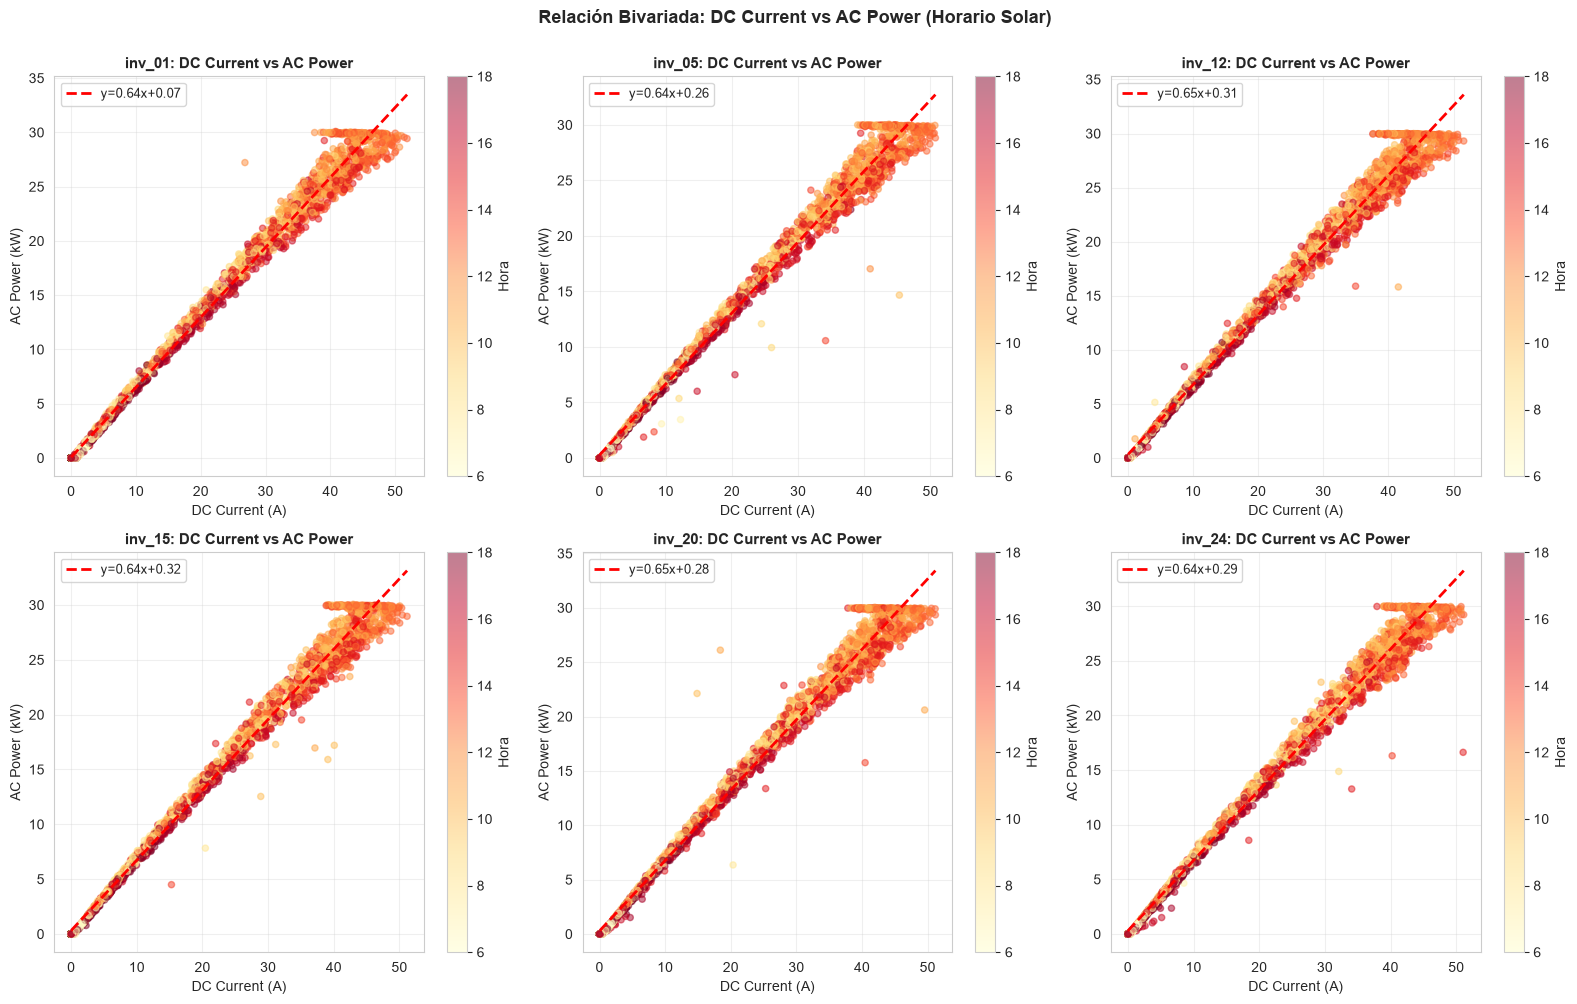

✓ Gráfico 4 (Bivariado DC vs AC) completado


In [65]:
np.random.seed(42)
sample_indices = np.random.choice(len(df_clean), size=min(5000, len(df_clean)), replace=False)
df_sample = df_clean.iloc[sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

selected_inversors = [1, 5, 12, 15, 20, 24]
for plot_idx, inv_num in enumerate(selected_inversors):
    ax = axes[plot_idx]
    
    dc_current_col = inversor_columns[inv_num]['dc_current']
    ac_power_col = inversor_columns[inv_num]['ac_power']
    
    if dc_current_col and ac_power_col:

        daytime_df = df_sample[df_sample['is_daytime']]
        i_dc = daytime_df[dc_current_col].values
        p_ac = daytime_df[ac_power_col].values
        

        scatter = ax.scatter(i_dc, p_ac, s=20, alpha=0.5, c=daytime_df['hour'].values, cmap='YlOrRd')
       
        valid_mask = (i_dc > 0) & (p_ac >= 0)
        if valid_mask.sum() > 10:
            z = np.polyfit(i_dc[valid_mask], p_ac[valid_mask], 1)
            p = np.poly1d(z)
            i_dc_line = np.linspace(i_dc[valid_mask].min(), i_dc[valid_mask].max(), 100)
            ax.plot(i_dc_line, p(i_dc_line), 'r--', linewidth=2, label=f'y={z[0]:.2f}x+{z[1]:.2f}')
        
        ax.set_xlabel('DC Current (A)', fontsize=10)
        ax.set_ylabel('AC Power (kW)', fontsize=10)
        ax.set_title(f'inv_{inv_num:02d}: DC Current vs AC Power', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Hora')

plt.suptitle('Relación Bivariada: DC Current vs AC Power (Horario Solar)', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Gráfico 4 (Bivariado DC vs AC) completado")


In [68]:
print("RESUMEN EJECUTIVO: ANÁLISIS DE EFICIENCIA EN PARQUE FOTOVOLTAICO")

print("\n KPI 1: TASA DE INVERSORES ANÓMALOS")

print(f"   Inversores con eficiencia bajo el umbral: {len(anomalous_inversors)}")
print(f"   Porcentaje: {kpi1_rate:.1f}%")
print(
    f"   Meta (≤10%): "
    f"{'✓ CUMPLIDA' if kpi1_rate <= 10 else '✗ NO CUMPLIDA'}"
)

if len(anomalous_inversors) > 0:
    print("\n   → Inversores que requieren revisión:")

    for _, row in anomalous_inversors.iterrows():
        print(
            f"     • {row['Inversor']}: "
            f"eficiencia {row['Eficiencia Media']:.4f} "
            f"(umbral: {p10_efficiency:.4f})"
        )


print("\n KPI 2: ÍNDICE DE DESVIACIÓN DE EFICIENCIA (DEI)")

total_degraded = (
    len(dei_alerts_moderate)
    + len(dei_alerts_critical)
)

print(
    f"   Inversores con degradación >10%: "
    f"{total_degraded}"
)

if len(dei_alerts_critical) > 0:

    print(
        f"   Críticos (>20%): "
        f"{len(dei_alerts_critical)} "
        f"→ Revisión URGENTE"
    )

    for inv_num, dei in dei_alerts_critical:

        print(
            f"     • inv_{inv_num:02d}: "
            f"{dei:+.1f}% de degradación"
        )

if len(dei_alerts_moderate) > 0:

    print(
        f"   Moderados (10-20%): "
        f"{len(dei_alerts_moderate)} "
        f"→ Monitoreo cercano"
    )

print(f"\n CLUSTERING (K={optimal_k_valid})")

print(
    f"   Silhouette Score: "
    f"{silhouette_scores_valid[optimal_k_valid - 2]:.4f}"
)

print(
    f"   Los inversores fueron agrupados "
    f"en {optimal_k_valid} clústeres "
    f"según sus patrones de eficiencia."
)

print("\n RECOMENDACIONES PRIORIZADAS:")

if len(anomalous_inversors) > 0:

    print("\n1. ALERTA INMEDIATA (próximas 2 semanas):")

    for _, row in anomalous_inversors.iterrows():

        print(
            f"   □ Revisar {row['Inversor']}: "
            f"eficiencia {row['Eficiencia Media']:.1%} "
            f"→ Posible falla electrónica"
        )

if len(dei_alerts_critical) > 0:

    print("\n2. MANTENIMIENTO PREVENTIVO (próximo mes):")

    for inv_num, dei in dei_alerts_critical:

        print(
            f"   □ Inspeccionar inv_{inv_num:02d}: "
            f"degradación {dei:.1f}% "
            f"→ Limpieza de paneles / "
            f"Cambio de componentes"
        )


print("\n3. MONITOREO CONTINUO:")

print(
    f"   □ Establecer alertas automáticas "
    f"para inversores con eficiencia "
    f"< {p25_efficiency:.4f}"
)

print(
    f"   □ Realizar auditoría mensual "
    f"de eficiencia comparativa"
)

print(
    f"   □ Implementar reentrenamiento "
    f"de modelos cada trimestre "
    f"(Data Drift)"
)


RESUMEN EJECUTIVO: ANÁLISIS DE EFICIENCIA EN PARQUE FOTOVOLTAICO

 KPI 1: TASA DE INVERSORES ANÓMALOS
   Inversores con eficiencia bajo el umbral: 3
   Porcentaje: 12.5%
   Meta (≤10%): ✗ NO CUMPLIDA

   → Inversores que requieren revisión:
     • inv_13: eficiencia 0.8929 (umbral: 0.8944)
     • inv_01: eficiencia 0.8763 (umbral: 0.8944)
     • inv_05: eficiencia 0.6551 (umbral: 0.8944)

 KPI 2: ÍNDICE DE DESVIACIÓN DE EFICIENCIA (DEI)
   Inversores con degradación >10%: 1
   Moderados (10-20%): 1 → Monitoreo cercano

 CLUSTERING (K=2)
   Silhouette Score: 0.5188
   Los inversores fueron agrupados en 2 clústeres según sus patrones de eficiencia.

 RECOMENDACIONES PRIORIZADAS:

1. ALERTA INMEDIATA (próximas 2 semanas):
   □ Revisar inv_13: eficiencia 89.3% → Posible falla electrónica
   □ Revisar inv_01: eficiencia 87.6% → Posible falla electrónica
   □ Revisar inv_05: eficiencia 65.5% → Posible falla electrónica

3. MONITOREO CONTINUO:
   □ Establecer alertas automáticas para inversor

In [70]:
print("RANKING DE ALERTAS: INVERSORES CON BAJO RENDIMIENTO (ENERGY_WEIGHTED)")

ranking_ew_df = pd.DataFrame([
    {
        'Inversor': f'inv_{inv:02d}',
        'Eficiencia (energy_weighted)': efficiency_data[inv]['energy_weighted'],
        'Eficiencia (mean)': efficiency_data[inv]['mean'],
        'Desv. Std': efficiency_data[inv]['std'],
        'Cluster': cluster_assignment_valid.get(inv, 'N/A')
    }
    for inv in inv_nums_valid
])

ranking_ew_sorted = ranking_ew_df.sort_values('Eficiencia (energy_weighted)', ascending=False).reset_index(drop=True)
ranking_ew_sorted['Rango'] = range(1, len(ranking_ew_sorted) + 1)

p10_ew = ranking_ew_sorted['Eficiencia (energy_weighted)'].quantile(0.10)
p25_ew = ranking_ew_sorted['Eficiencia (energy_weighted)'].quantile(0.25)
p90_ew = ranking_ew_sorted['Eficiencia (energy_weighted)'].quantile(0.90)

print(ranking_ew_sorted[['Rango', 'Inversor', 'Eficiencia (energy_weighted)', 'Eficiencia (mean)', 'Desv. Std', 'Cluster']].to_string(index=False))

print(f"\n UMBRALES ESTADÍSTICOS (22 INVERSORES VÁLIDOS) ")
print(f"Percentil 90 (P90): {p90_ew:.4f}")
print(f"Percentil 75 (Q3):  {ranking_ew_sorted['Eficiencia (energy_weighted)'].quantile(0.75):.4f}")
print(f"Mediana (P50):      {ranking_ew_sorted['Eficiencia (energy_weighted)'].median():.4f}")
print(f"Percentil 25 (Q1):  {p25_ew:.4f}")
print(f"Percentil 10 (P10): {p10_ew:.4f} ← Umbral de BAJO rendimiento")

alertas_ew = ranking_ew_sorted[ranking_ew_sorted['Eficiencia (energy_weighted)'] < p10_ew]
tasa_alertas = (len(alertas_ew) / len(ranking_ew_sorted)) * 100

print(f"\n KPI 1: TASA DE INVERSORES ANÓMALOS (ENERGY_WEIGHTED) ")
print(f"Inversores con eficiencia < P10 ({p10_ew:.4f}): {len(alertas_ew)}")
print(f"Porcentaje: {tasa_alertas:.1f}% ({len(alertas_ew)}/{len(ranking_ew_sorted)})")
print(f"Meta (≤10%): {'✓ CUMPLIDA' if tasa_alertas <= 10 else '✗ NO CUMPLIDA'}")

if len(alertas_ew) > 0:
    print(f"\n INVERSORES EN ALERTA (< P10):")
    for idx, row in alertas_ew.iterrows():
        cluster_id = row['Cluster']
        print(f"   {row['Rango']:2d}. {row['Inversor']}: eff={row['Eficiencia (energy_weighted)']:.4f} | "
              f"Cluster {int(cluster_id)} | mean={row['Eficiencia (mean)']:.4f} ± {row['Desv. Std']:.4f}")

print(f"\n EXCLUSIONES DOCUMENTADAS:")
print(f"   inv_05: Sin sensor dc_voltage real → Eficiencia estimada no confiable")
print(f"   inv_07: Voltaje DC corrupto (hasta 1.38E12 V) → Datos inválidos para benchmarking")
print(f"   Análisis de clustering: Basado en 22 inversores válidos únicamente")


RANKING DE ALERTAS: INVERSORES CON BAJO RENDIMIENTO (ENERGY_WEIGHTED)
 Rango Inversor  Eficiencia (energy_weighted)  Eficiencia (mean)  Desv. Std  Cluster
     1   inv_14                      0.985147           0.945436   0.139438        1
     2   inv_22                      0.984424           0.958450   0.108359        1
     3   inv_10                      0.983031           0.937345   0.151714        1
     4   inv_12                      0.981713           0.936068   0.154270        1
     5   inv_24                      0.981676           0.943586   0.134287        1
     6   inv_09                      0.981514           0.935584   0.153970        1
     7   inv_11                      0.979641           0.946845   0.125427        1
     8   inv_15                      0.978815           0.933354   0.150554        1
     9   inv_18                      0.978540           0.933368   0.150470        1
    10   inv_03                      0.978234           0.922220   0.173736     

ANÁLISIS SUPERVISADO — MODELOS PREDICTIVOS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MODELOS SUPERVISADOS (REGRESIÓN)")

print("\n PREPARACIÓN DE DATOS")
print(f"   Inversores para entrenar: 22 (excluyendo inv_05, inv_07)")
print(f"   Variable objetivo: AC Power (kW)")
print(f"   Variables predictoras: DC Current (A), DC Voltage (V)\n")

if 'df_clean' not in globals():
    df = pd.read_csv('2107_electrical_data.csv')
    df['measured_on'] = pd.to_datetime(df['measured_on'])
    cutoff_date = pd.Timestamp('2023-11-02 00:00:00')
    df_clean = df[df['measured_on'] < cutoff_date].copy()
    df_clean['date'] = df_clean['measured_on'].dt.date
    df_clean['hour'] = df_clean['measured_on'].dt.hour
    df_clean['is_daytime'] = (df_clean['hour'] >= 6) & (df_clean['hour'] <= 18)

if 'inversor_columns' not in globals():
    inversor_columns = {}
    for inv_num in range(1, 25):
        inv_prefix = f'inv_{inv_num:02d}_'
        inv_cols = [col for col in df_clean.columns if col.startswith(inv_prefix)]
        inversor_columns[inv_num] = {
            'dc_current': None,
            'dc_voltage': None,
            'ac_current': None,
            'ac_voltage': None,
            'ac_power': None,
            'raw_columns': inv_cols
        }
        for col in inv_cols:
            if 'dc_current' in col:
                inversor_columns[inv_num]['dc_current'] = col
            elif 'dc_voltage' in col:
                inversor_columns[inv_num]['dc_voltage'] = col
            elif 'ac_current' in col:
                inversor_columns[inv_num]['ac_current'] = col
            elif 'ac_voltage' in col:
                inversor_columns[inv_num]['ac_voltage'] = col
            elif 'ac_power' in col or 'ac_power_iinv' in col:
                inversor_columns[inv_num]['ac_power'] = col

if 'inv_nums_valid' not in globals():
    inv_nums_valid = sorted([
        inv_num for inv_num in range(1, 25)
        if inversor_columns[inv_num]['dc_current'] and inversor_columns[inv_num]['dc_voltage'] and inversor_columns[inv_num]['ac_power']
    ])

fecha_inicio = pd.to_datetime('2023-11-02').date()
fecha_fin = pd.to_datetime('2023-11-07').date()

periodo_corrupto = (df_clean['date'] >= fecha_inicio) & (df_clean['date'] <= fecha_fin)
df_clean_model = df_clean[~periodo_corrupto].copy()
print(f"   Filas excluidas por periodo corrupto: {periodo_corrupto.sum():,}")
print(f"   Filas disponibles tras exclusión: {len(df_clean_model):,}\n")

X_data = []
y_data = []
date_data = []

daytime_df = df_clean_model[df_clean_model['is_daytime']]

for inv_num in inv_nums_valid:
    dc_current_col = inversor_columns[inv_num]['dc_current']
    dc_voltage_col = inversor_columns[inv_num]['dc_voltage']
    ac_power_col = inversor_columns[inv_num]['ac_power']

    if dc_current_col and dc_voltage_col and ac_power_col:
        i_dc = daytime_df[dc_current_col].values
        v_dc = daytime_df[dc_voltage_col].values
        p_ac = daytime_df[ac_power_col].values
        fechas = daytime_df['date'].values

        valid_mask = (p_ac > 0.01) & (i_dc > 0) & (v_dc > 0) & (v_dc < 2000)

        X_inv = np.column_stack((i_dc[valid_mask], v_dc[valid_mask]))
        y_inv = p_ac[valid_mask]
        fechas_inv = fechas[valid_mask]

        X_data.append(X_inv)
        y_data.append(y_inv)
        date_data.append(fechas_inv)

X_full = np.vstack(X_data)
y_full = np.concatenate(y_data)
dates_full = np.concatenate(date_data)

print(f"✓ Muestras de entrenamiento: {len(X_full):,}")
print(f"✓ Rango AC Power: {y_full.min():.3f} — {y_full.max():.3f} kW")
print(f"✓ Rango DC Current: {X_full[:, 0].min():.3f} — {X_full[:, 0].max():.3f} A")
print(f"✓ Rango DC Voltage: {X_full[:, 1].min():.3f} — {X_full[:, 1].max():.3f} V\n")

sample_size = min(120_000, len(X_full))
rng = np.random.RandomState(42)
idx_sample = rng.choice(len(X_full), size=sample_size, replace=False)
X_full = X_full[idx_sample]
y_full = y_full[idx_sample]
dates_full = dates_full[idx_sample]

dates_full_ts = pd.Series(pd.to_datetime(dates_full))

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
print(f"[Split aleatorio] Train/Test: {len(X_train):,} / {len(X_test):,} muestras")

fecha_corte = dates_full_ts.quantile(0.8)
mask_train_fecha = (dates_full_ts <= fecha_corte).values
mask_test_fecha = ~mask_train_fecha

X_train_f, y_train_f = X_full[mask_train_fecha], y_full[mask_train_fecha]
X_test_f, y_test_f = X_full[mask_test_fecha], y_full[mask_test_fecha]
print(f"[Split por fecha] Train/Test: {len(X_train_f):,} / {len(X_test_f):,} muestras "
      f"(corte: {fecha_corte})\n")

print(" REGRESIÓN LINEAL")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

r2_train_lr = r2_score(y_train, y_pred_lr_train)
r2_test_lr = r2_score(y_test, y_pred_lr_test)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_test_lr = mean_absolute_error(y_test, y_pred_lr_test)

print(f"\nCoeficientes:")
print(f"  Pendiente (DC Current): {lr_model.coef_[0]:.6f} kW/A")
print(f"  Pendiente (DC Voltage): {lr_model.coef_[1]:.6f} kW/V")
print(f"  Intercepto: {lr_model.intercept_:.6f} kW")

print(f"\nRendimiento (split aleatorio):")
print(f"  R² (Train): {r2_train_lr:.4f}")
print(f"  R² (Test):  {r2_test_lr:.4f}")
print(f"  RMSE (Test): {rmse_test_lr:.4f} kW")
print(f"  MAE (Test):  {mae_test_lr:.4f} kW")

lr_model_f = LinearRegression()
lr_model_f.fit(X_train_f, y_train_f)
r2_test_lr_f = r2_score(y_test_f, lr_model_f.predict(X_test_f))
print(f"\nRendimiento (split por FECHA, sin fuga temporal):")
print(f"  R² (Test): {r2_test_lr_f:.4f}")
print(f"  Diferencia vs. split aleatorio: {(r2_test_lr - r2_test_lr_f)*100:+.2f} puntos")
if (r2_test_lr - r2_test_lr_f) > 0.03:
    print(f"  Diferencia notable → el split aleatorio probablemente sobreestimaba el desempeño")
else:
    print(f"  ✓ Diferencia pequeña → la relación física (P=I×V) domina, poca fuga real")

cv_kfold = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr_model, X_full, y_full, cv=cv_kfold, scoring='r2')
print(f"\n  R² CV (3-fold, sampled): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

print("\nRANDOM FOREST REGRESSOR")

rf_sample_size = min(80_000, len(X_train))
rng_rf = np.random.RandomState(42)
rf_idx = rng_rf.choice(len(X_train), size=rf_sample_size, replace=False)

rf_model = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=1)
rf_model.fit(X_train[rf_idx], y_train[rf_idx])

y_pred_rf_train = rf_model.predict(X_train[rf_idx])
y_pred_rf_test = rf_model.predict(X_test)

r2_train_rf = r2_score(y_train[rf_idx], y_pred_rf_train)
r2_test_rf = r2_score(y_test, y_pred_rf_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_test_rf = mean_absolute_error(y_test, y_pred_rf_test)

print(f"\nImportancia de features:")
print(f"  DC Current: {rf_model.feature_importances_[0]:.4f}")
print(f"  DC Voltage: {rf_model.feature_importances_[1]:.4f}")

print(f"\nRendimiento (split aleatorio):")
print(f"  R² (Train): {r2_train_rf:.4f}")
print(f"  R² (Test):  {r2_test_rf:.4f}")
print(f"  RMSE (Test): {rmse_test_rf:.4f} kW")
print(f"  MAE (Test):  {mae_test_rf:.4f} kW")

rf_idx_f = rng_rf.choice(len(X_train_f), size=min(50_000, len(X_train_f)), replace=False)
rf_model_f = RandomForestRegressor(n_estimators=20, max_depth=8, random_state=42, n_jobs=1)
rf_model_f.fit(X_train_f[rf_idx_f], y_train_f[rf_idx_f])
r2_test_rf_f = r2_score(y_test_f, rf_model_f.predict(X_test_f))
print(f"\nRendimiento (split por FECHA, sin fuga temporal):")
print(f"  R² (Test): {r2_test_rf_f:.4f}")
print(f"  Diferencia vs. split aleatorio: {(r2_test_rf - r2_test_rf_f)*100:+.2f} puntos")

cv_sample_size = min(40_000, len(X_full))
cv_idx = rng.choice(len(X_full), size=cv_sample_size, replace=False)
X_full_cv = X_full[cv_idx]
y_full_cv = y_full[cv_idx]
cv_scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=8, max_depth=4, random_state=42, n_jobs=1),
    X_full_cv,
    y_full_cv,
    cv=KFold(n_splits=2, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=1
)
print(f"\n  R² CV (2-fold, sampled): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

print(f"\n" + "="*80)
print("COMPARACIÓN DE MODELOS (SPLIT ALEATORIO)")
print("="*80)
print(f"\n{'Métrica':<25} {'Regresión Lineal':<20} {'Random Forest':<20}")
print("-" * 65)
print(f"{'R² (Test)':<25} {r2_test_lr:<20.4f} {r2_test_rf:<20.4f}")
print(f"{'RMSE (Test)':<25} {rmse_test_lr:<20.4f} {rmse_test_rf:<20.4f}")
print(f"{'MAE (Test)':<25} {mae_test_lr:<20.4f} {mae_test_rf:<20.4f}")
print(f"{'R² CV Media (shuffled)':<25} {cv_scores_lr.mean():<20.4f} {cv_scores_rf.mean():<20.4f}")
print(f"{'R² (split por fecha)':<25} {r2_test_lr_f:<20.4f} {r2_test_rf_f:<20.4f}")

mejor_modelo = "Random Forest" if r2_test_rf > r2_test_lr else "Regresión Lineal"
print(f"\n✓ Mejor modelo (por R² test aleatorio): {mejor_modelo}")
print(f"   Ganancia: {abs(r2_test_rf - r2_test_lr)*100:.2f}%")


MODELOS SUPERVISADOS (REGRESIÓN)

 PREPARACIÓN DE DATOS
   Inversores para entrenar: 22 (excluyendo inv_05, inv_07)
   Variable objetivo: AC Power (kW)
   Variables predictoras: DC Current (A), DC Voltage (V)

   Filas excluidas por periodo corrupto: 0
   Filas disponibles tras exclusión: 631,224

✓ Muestras de entrenamiento: 6,264,850
✓ Rango AC Power: 0.011 — 103.710 kW
✓ Rango DC Current: 0.001 — 55.843 A
✓ Rango DC Voltage: 284.013 — 1750.755 V

[Split aleatorio] Train/Test: 96,000 / 24,000 muestras
[Split por fecha] Train/Test: 96,038 / 23,962 muestras (corte: 2022-09-12 00:00:00)

 REGRESIÓN LINEAL


NameError: name 'lr_model_f' is not defined

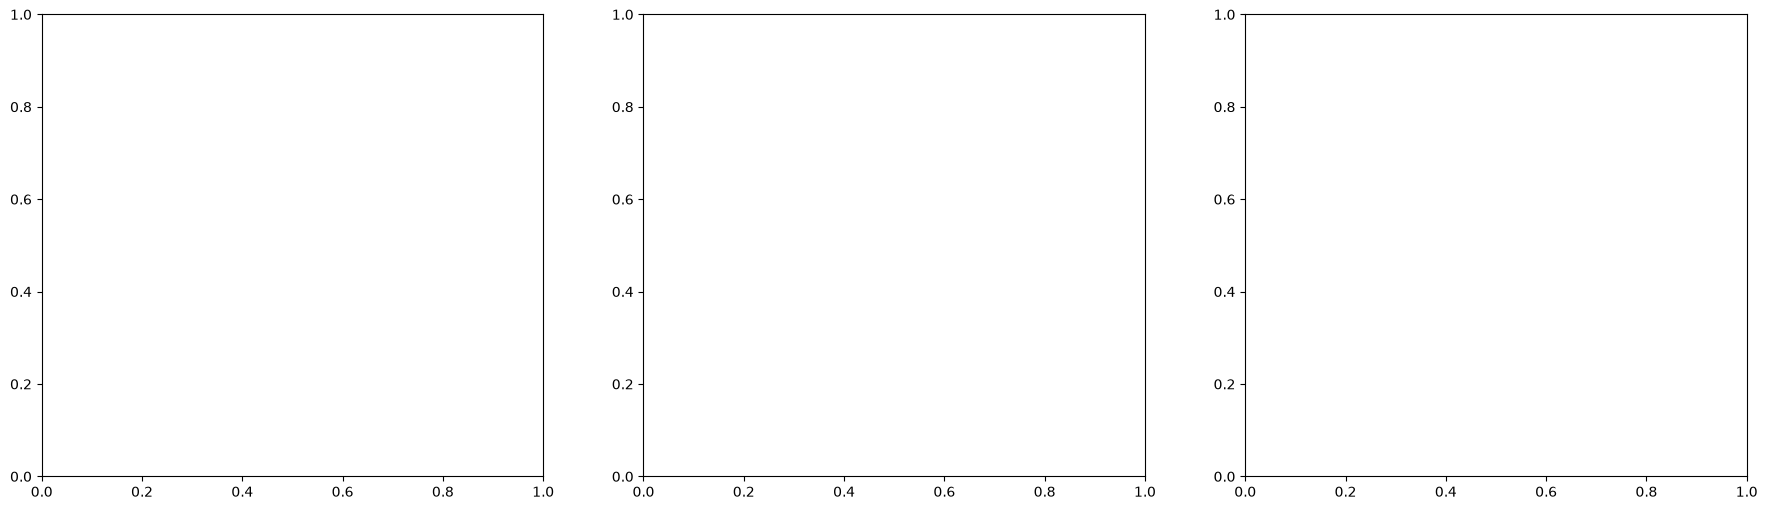

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

y_pred_lr_test_f = lr_model_f.predict(X_test_f)
y_pred_rf_test_f = rf_model_f.predict(X_test_f)

ax = axes[0]
sample_indices_test = np.random.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
ax.scatter(y_test[sample_indices_test], y_pred_lr_test[sample_indices_test], alpha=0.3, s=20, label='Predicciones')
min_val, max_val = y_test.min(), y_test.max()
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Línea ideal')
ax.set_xlabel('Potencia AC Real (kW)', fontsize=11)
ax.set_ylabel('Potencia AC Predicha (kW)', fontsize=11)
ax.set_title(f'Regresión Lineal (split aleatorio)\nR² = {r2_test_lr:.4f}', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_test[sample_indices_test], y_pred_rf_test[sample_indices_test], alpha=0.3, s=20, label='Predicciones')
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Línea ideal')
ax.set_xlabel('Potencia AC Real (kW)', fontsize=11)
ax.set_ylabel('Potencia AC Predicha (kW)', fontsize=11)
ax.set_title(f'Random Forest (split aleatorio)\nR² = {r2_test_rf:.4f}', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
sample_idx_f = np.random.choice(len(y_test_f), size=min(2000, len(y_test_f)), replace=False)
ax.scatter(y_test_f[sample_idx_f], y_pred_rf_test_f[sample_idx_f], alpha=0.3, s=20, color='orange', label='Predicciones')
min_val_f, max_val_f = y_test_f.min(), y_test_f.max()
ax.plot([min_val_f, max_val_f], [min_val_f, max_val_f], 'r--', linewidth=2, label='Línea ideal')
ax.set_xlabel('Potencia AC Real (kW)', fontsize=11)
ax.set_ylabel('Potencia AC Predicha (kW)', fontsize=11)
ax.set_title(f'Random Forest (split por FECHA)\nR² = {r2_test_rf_f:.4f}', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Modelos Supervisados: Predicción de Potencia AC', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Visualización completada")


FORECASTING DE SERIES DE TIEMPO

FORECASTING DE SERIES DE TIEMPO

 CÁLCULO DE ENERGÍA DIARIA
  Columnas de potencia AC detectadas: 24
✓ Período de series: 2017-11-01 00:00:00 a 2023-11-01 00:00:00
✓ Total de días: 2192
✓ Energía diaria promedio: 3.76 MWh
✓ Desviación estándar: 1.56 MWh
✓ Min/Max: 0.00 — 6.23 MWh

 ANÁLISIS DE ESTACIONARIEDAD
ADF Test Statistic: -5.192239
p-value: 0.000009
Series es estacionaria (α=0.05)

Después de diferenciación:
ADF Test Statistic: -13.050850
p-value: 0.000000
Series es estacionaria (α=0.05)

 DESCOMPOSICIÓN SEMANAL
✓ Componentes extraídos:
   - Tendencia: 3.76 ± 1.25 MWh
   - Estacionalidad: amplitud = 0.22 MWh
   - Residuos: media = 0.000853, σ = 0.89 MWh


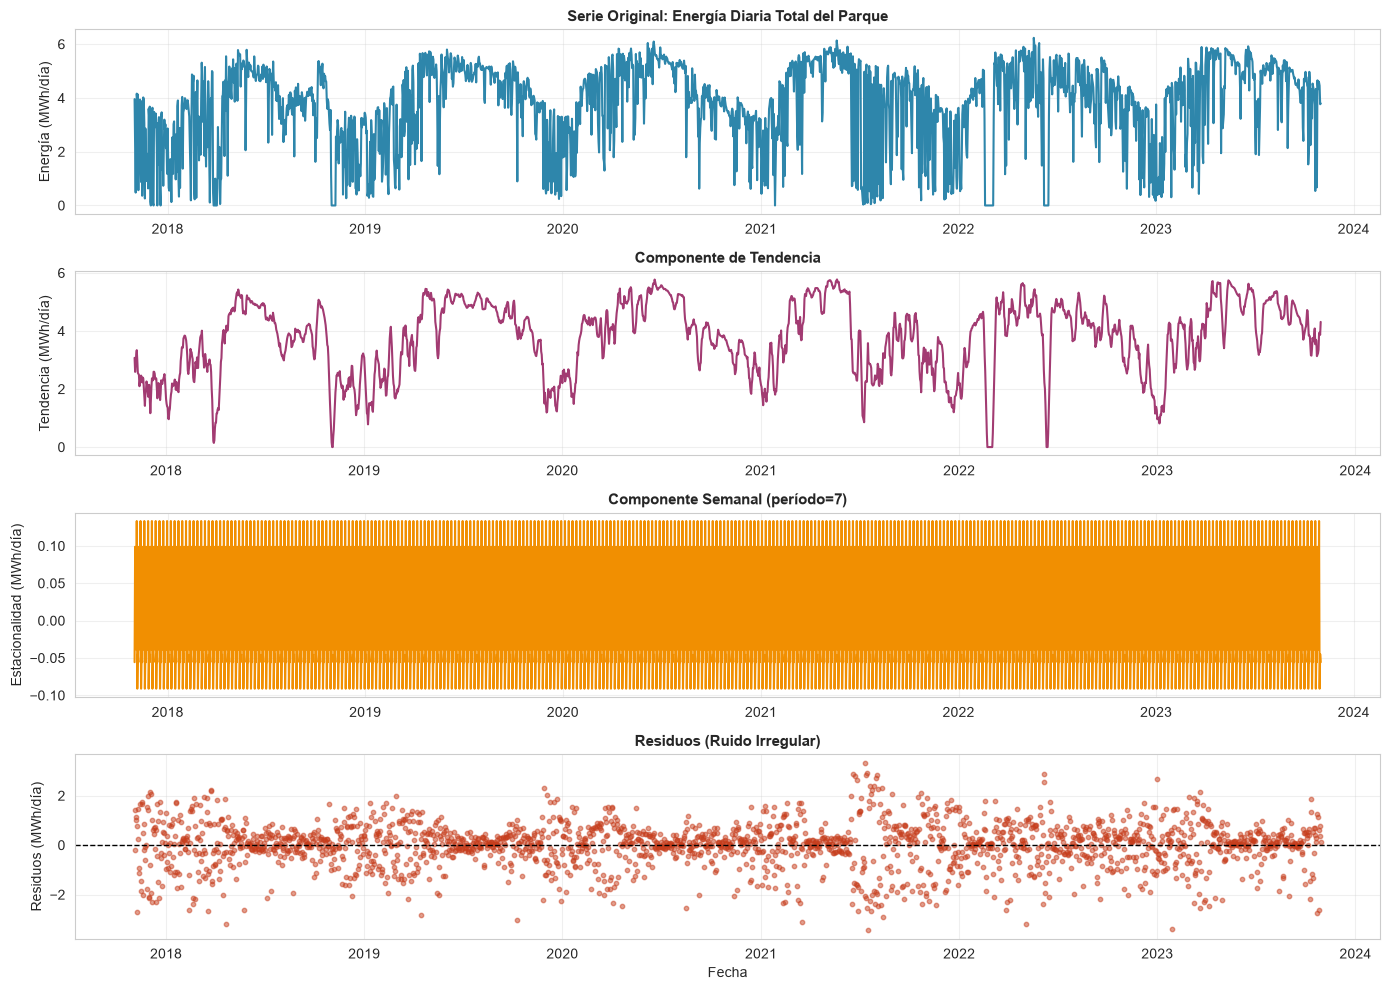


✓ Visualización de descomposición completada


In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings('ignore')

print("="*80)
print("FORECASTING DE SERIES DE TIEMPO")
print("="*80)

print("\n CÁLCULO DE ENERGÍA DIARIA")

ac_power_cols = [
    col for col in df_clean.columns
    if 'ac_power' in col.lower()
]

print(f"  Columnas de potencia AC detectadas: {len(ac_power_cols)}")

daily_energy = (
    df_clean
    .groupby('date')[ac_power_cols]
    .sum()
    * (5/60)
)

daily_energy_total = daily_energy.sum(axis=1)
daily_energy_total = daily_energy_total / 1000

ts_data = pd.Series(
    daily_energy_total.values,
    index=pd.to_datetime(daily_energy_total.index)
)

ts_data = ts_data.sort_index()
ts_data = ts_data.dropna()

print(f"✓ Período de series: {ts_data.index.min()} a {ts_data.index.max()}")
print(f"✓ Total de días: {len(ts_data)}")
print(f"✓ Energía diaria promedio: {ts_data.mean():.2f} MWh")
print(f"✓ Desviación estándar: {ts_data.std():.2f} MWh")
print(f"✓ Min/Max: {ts_data.min():.2f} — {ts_data.max():.2f} MWh")

print(f"\n ANÁLISIS DE ESTACIONARIEDAD")

adf_result = adfuller(ts_data, autolag='AIC')

print(f"ADF Test Statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print(
    f"Series es "
    f"{'estacionaria' if adf_result[1] < 0.05 else 'NO estacionaria'} "
    f"(α=0.05)"
)

ts_diff = ts_data.diff().dropna()

adf_result_diff = adfuller(ts_diff, autolag='AIC')

print(f"\nDespués de diferenciación:")
print(f"ADF Test Statistic: {adf_result_diff[0]:.6f}")
print(f"p-value: {adf_result_diff[1]:.6f}")
print(
    f"Series es "
    f"{'estacionaria' if adf_result_diff[1] < 0.05 else 'NO estacionaria'} "
    f"(α=0.05)"
)

print(f"\n DESCOMPOSICIÓN SEMANAL")

if len(ts_data) >= 14:

    decomposition = seasonal_decompose(
        ts_data,
        model='additive',
        period=7
    )

    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    print(f"✓ Componentes extraídos:")
    print(
        f"   - Tendencia: "
        f"{trend.dropna().mean():.2f} ± "
        f"{trend.dropna().std():.2f} MWh"
    )

    print(
        f"   - Estacionalidad: amplitud = "
        f"{seasonal.max() - seasonal.min():.2f} MWh"
    )

    print(
        f"   - Residuos: media = "
        f"{residual.dropna().mean():.6f}, "
        f"σ = {residual.dropna().std():.2f} MWh"
    )

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))

    axes[0].plot(
        ts_data.index,
        ts_data.values,
        linewidth=1.5,
        color='#2E86AB'
    )

    axes[0].set_ylabel('Energía (MWh/día)', fontsize=10)
    axes[0].set_title(
        'Serie Original: Energía Diaria Total del Parque',
        fontsize=11,
        fontweight='bold'
    )
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        trend.index,
        trend.values,
        linewidth=1.5,
        color='#A23B72'
    )

    axes[1].set_ylabel('Tendencia (MWh/día)', fontsize=10)
    axes[1].set_title(
        'Componente de Tendencia',
        fontsize=11,
        fontweight='bold'
    )
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(
        seasonal.index,
        seasonal.values,
        linewidth=1.5,
        color='#F18F01'
    )

    axes[2].set_ylabel('Estacionalidad (MWh/día)', fontsize=10)
    axes[2].set_title(
        'Componente Semanal (período=7)',
        fontsize=11,
        fontweight='bold'
    )
    axes[2].grid(True, alpha=0.3)

    axes[3].scatter(
        residual.index,
        residual.values,
        s=10,
        alpha=0.5,
        color='#C73E1D'
    )

    axes[3].axhline(
        y=0,
        color='black',
        linestyle='--',
        linewidth=1
    )

    axes[3].set_ylabel(
        'Residuos (MWh/día)',
        fontsize=10
    )

    axes[3].set_xlabel(
        'Fecha',
        fontsize=10
    )

    axes[3].set_title(
        'Residuos (Ruido Irregular)',
        fontsize=11,
        fontweight='bold'
    )

    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n✓ Visualización de descomposición completada")

else:
    print(
        f"❌ No hay suficientes datos "
        f"para descomposición estacional "
        f"(n={len(ts_data)}, mínimo=14)"
    )

In [ ]:
split_idx = int(len(ts_data) * 0.8)
train_ts = ts_data[:split_idx]
test_ts = ts_data[split_idx:]

arima_success = False
hw_success = False

print(f"\n TRAIN-TEST SPLIT ")
print(f"Train: {train_ts.index[0].date()} a {train_ts.index[-1].date()} ({len(train_ts)} días)")
print(f"Test:  {test_ts.index[0].date()} a {test_ts.index[-1].date()} ({len(test_ts)} días)")

print(f"\n" + "="*80)
print("MODELO 1: ARIMA(1,1,1)")
print("="*80)

try:
    arima_model = ARIMA(train_ts, order=(1, 1, 1))
    arima_fit = arima_model.fit()
    
    forecast_arima = arima_fit.get_forecast(steps=len(test_ts))
    y_pred_arima = forecast_arima.predicted_mean
    ci_arima = forecast_arima.conf_int()
    
    rmse_arima = np.sqrt(mean_squared_error(test_ts, y_pred_arima))
    mae_arima = mean_absolute_error(test_ts, y_pred_arima)
    mape_arima = np.mean(np.abs((test_ts.values - y_pred_arima.values) / test_ts.values)) * 100
    
    print(f"\nResumen del modelo:")
    print(f"  AIC: {arima_fit.aic:.2f}")
    print(f"  BIC: {arima_fit.bic:.2f}")
    
    print(f"\nRendimiento (Test):")
    print(f"  RMSE: {rmse_arima:.4f} MWh")
    print(f"  MAE:  {mae_arima:.4f} MWh")
    print(f"  MAPE: {mape_arima:.2f}%")
    
    arima_success = True
except Exception as e:
    print(f" Error en ARIMA: {e}")
    arima_success = False

print(f"\n" + "="*80)
print("MODELO 2: HOLT-WINTERS (Exponential Smoothing)")
print("="*80)

try:
    hw_model = ExponentialSmoothing(train_ts, seasonal_periods=7, trend='add', seasonal='add')
    hw_fit = hw_model.fit(optimized=True)
    
    forecast_hw = hw_fit.forecast(steps=len(test_ts))
    y_pred_hw = forecast_hw
    
    rmse_hw = np.sqrt(mean_squared_error(test_ts, y_pred_hw))
    mae_hw = mean_absolute_error(test_ts, y_pred_hw)
    mape_hw = np.mean(np.abs((test_ts.values - y_pred_hw.values) / test_ts.values)) * 100
    
    print(f"\nResumen del modelo:")
    print(f"  Smoothing level (α): {hw_fit.params['smoothing_level']:.4f}")
    print(f"  Smoothing trend (β): {hw_fit.params['smoothing_trend']:.4f}")
    print(f"  Smoothing seasonal (γ): {hw_fit.params['smoothing_seasonal']:.4f}")
    
    print(f"\nRendimiento (Test):")
    print(f"  RMSE: {rmse_hw:.4f} MWh")
    print(f"  MAE:  {mae_hw:.4f} MWh")
    print(f"  MAPE: {mape_hw:.2f}%")
    
    hw_success = True
except Exception as e:
    print(f" Error en Holt-Winters: {e}")
    hw_success = False

print(f"\n" + "="*80)
print("COMPARACIÓN DE MODELOS DE FORECASTING")
print("="*80)

if arima_success and hw_success:
    print(f"\n{'Métrica':<20} {'ARIMA(1,1,1)':<20} {'Holt-Winters':<20}")
    print("-" * 60)
    print(f"{'RMSE (MWh)':<20} {rmse_arima:<20.4f} {rmse_hw:<20.4f}")
    print(f"{'MAE (MWh)':<20} {mae_arima:<20.4f} {mae_hw:<20.4f}")
    print(f"{'MAPE (%)':<20} {mape_arima:<20.2f} {mape_hw:<20.2f}")
    
    mejor_modelo_ts = "Holt-Winters" if rmse_hw < rmse_arima else "ARIMA"
    mejora = abs(rmse_arima - rmse_hw) / max(rmse_arima, rmse_hw) * 100
    print(f"\n✓ Mejor modelo: {mejor_modelo_ts} (mejora: {mejora:.2f}%)")



 TRAIN-TEST SPLIT 
Train: 2017-11-01 a 2022-08-19 (1753 días)
Test:  2022-08-20 a 2023-11-01 (439 días)

MODELO 1: ARIMA(1,1,1)

Resumen del modelo:
  AIC: 5353.63
  BIC: 5370.03

Rendimiento (Test):
  RMSE: 1.4554 MWh
  MAE:  1.0781 MWh
  MAPE: 77.48%

MODELO 2: HOLT-WINTERS (Exponential Smoothing)
 Error en Holt-Winters: 'HoltWintersResults' object has no attribute 'get_forecast'

COMPARACIÓN DE MODELOS DE FORECASTING


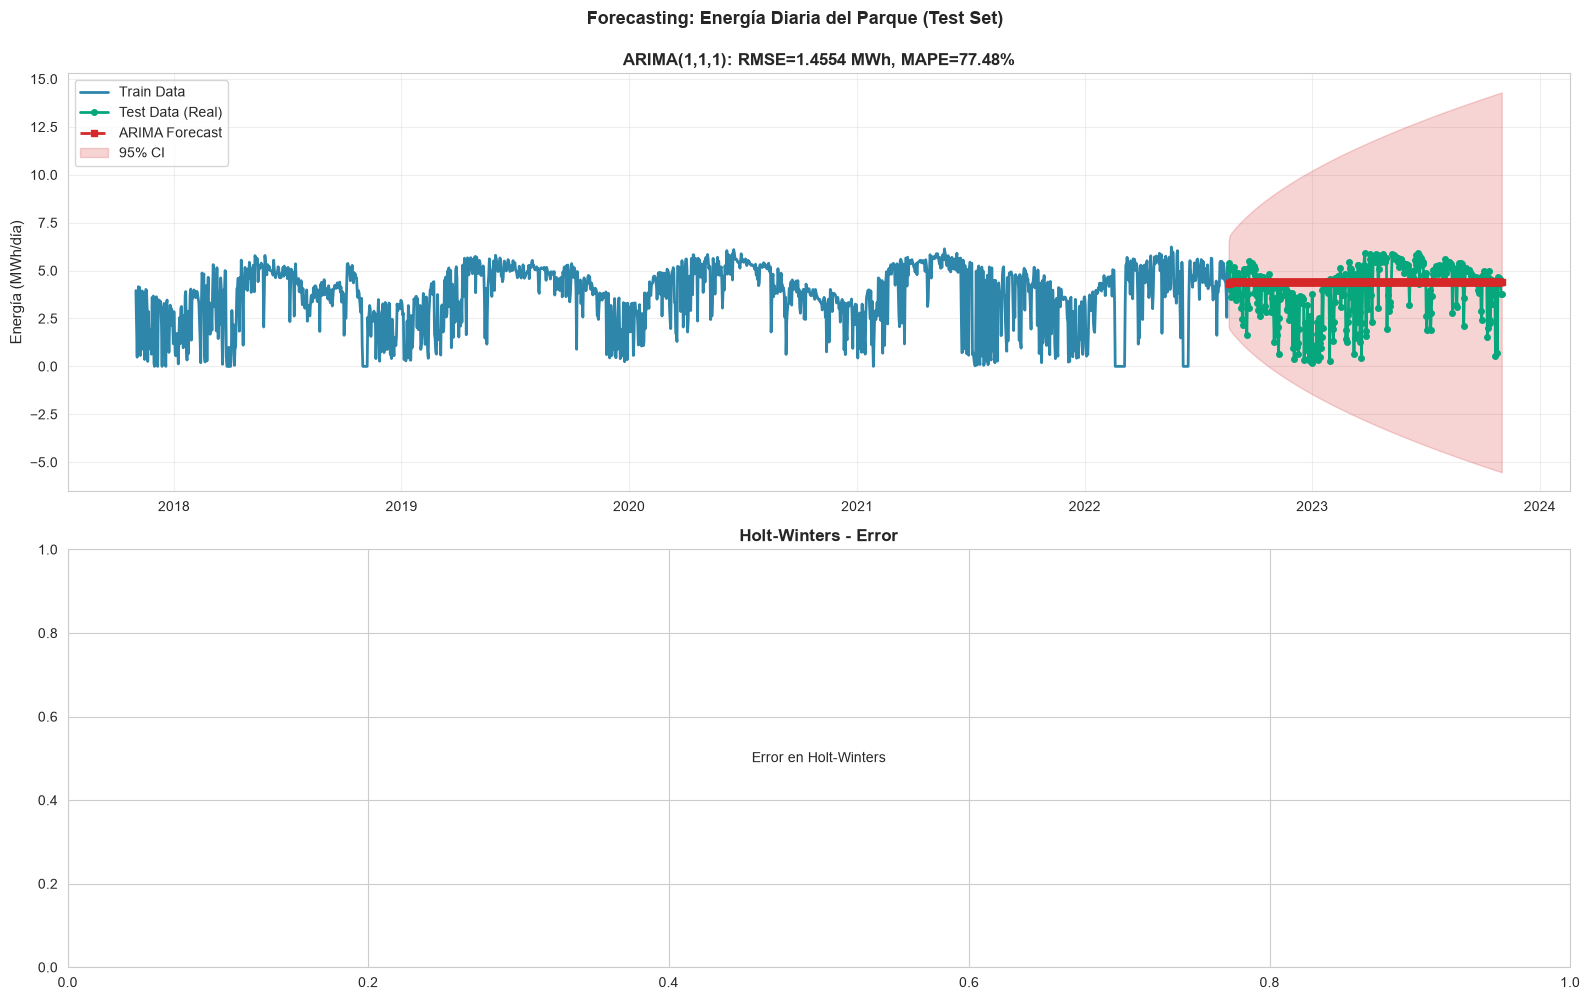


✓ Visualización de forecasts completada


In [51]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

if arima_success:
    ax = axes[0]
    ax.plot(train_ts.index, train_ts.values, linewidth=2, label='Train Data', color='#2E86AB')
    ax.plot(test_ts.index, test_ts.values, linewidth=2, label='Test Data (Real)', color='#06A77D', marker='o', markersize=4)
    ax.plot(test_ts.index, y_pred_arima.values, linewidth=2, label='ARIMA Forecast', color='#D62828', linestyle='--', marker='s', markersize=4)
    
    ax.fill_between(test_ts.index, ci_arima.iloc[:, 0], ci_arima.iloc[:, 1], alpha=0.2, color='#D62828', label='95% CI')
    
    ax.set_ylabel('Energía (MWh/día)', fontsize=11)
    ax.set_title(f'ARIMA(1,1,1): RMSE={rmse_arima:.4f} MWh, MAPE={mape_arima:.2f}%', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
else:
    ax = axes[0]
    ax.text(0.5, 0.5, 'Error en ARIMA', transform=ax.transAxes, ha='center', va='center')
    ax.set_title('ARIMA(1,1,1) - Error', fontsize=12, fontweight='bold')

if hw_success:
    ax = axes[1]
    ax.plot(train_ts.index, train_ts.values, linewidth=2, label='Train Data', color='#2E86AB')
    ax.plot(test_ts.index, test_ts.values, linewidth=2, label='Test Data (Real)', color='#06A77D', marker='o', markersize=4)
    ax.plot(test_ts.index, y_pred_hw.values, linewidth=2, label='Holt-Winters Forecast', color='#F18F01', linestyle='--', marker='s', markersize=4)
    
    ax.set_ylabel('Energía (MWh/día)', fontsize=11)
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_title(f'Holt-Winters: RMSE={rmse_hw:.4f} MWh, MAPE={mape_hw:.2f}%', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
else:
    ax = axes[1]
    ax.text(0.5, 0.5, 'Error en Holt-Winters', transform=ax.transAxes, ha='center', va='center')
    ax.set_title('Holt-Winters - Error', fontsize=12, fontweight='bold')

plt.suptitle('Forecasting: Energía Diaria del Parque (Test Set)', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Visualización de forecasts completada")
